# ML Zoomcamp 2026 – Homework 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
data = Path("./data/car_fuel_efficiency_2026.csv").resolve()

df = pd.read_csv(data)
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  str    
 2   fuel_type            10000 non-null  str    
 3   drivetrain           10000 non-null  str    
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 1.1 MB


In [4]:
df.isna().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [5]:
df.nunique()

model_year              50
origin                   3
fuel_type                3
drivetrain               3
num_doors                4
engine_displacement    127
num_cylinders            5
horsepower             153
vehicle_weight         176
acceleration            93
fuel_efficiency_mpg    188
dtype: int64

Use only the following columns:

```
'engine_displacement'
'horsepower',
'vehicle_weight'
'model_year'
'fuel_efficiency_mpg'
```

Predict: fuel_efficiency_mpg

In [6]:
working_columns = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg"
]

In [7]:
df["horsepower"].median()

np.float64(254.0)

In [8]:
df["horsepower"].mean()

np.float64(254.44601556505535)

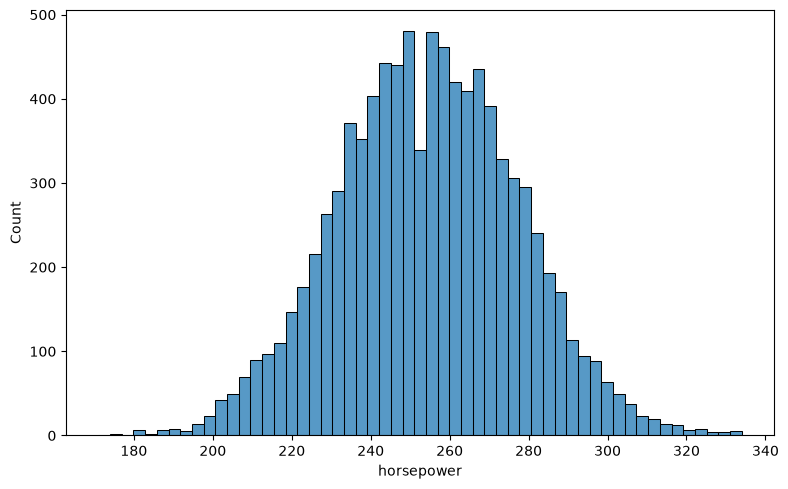

In [9]:
fig, ax = plt.subplots(figsize=(800, 500, "px"))

sns.histplot(df["horsepower"], ax=ax)

plt.tight_layout()

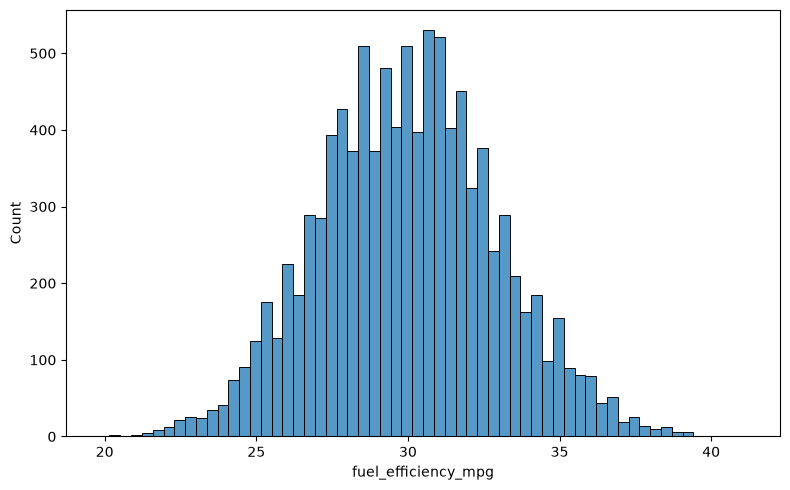

In [10]:
fig, ax = plt.subplots(figsize=(800, 500, "px"))

sns.histplot(df["fuel_efficiency_mpg"], ax=ax)

plt.tight_layout()

In [11]:
df.shape

(10000, 11)

In [12]:
df_model = df[working_columns]
df_model.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [13]:
# Calculate size of parts

nrows = len(df_model)

n_val = int(nrows * 0.2)
n_test = int(nrows * 0.2)
n_train = nrows - (n_val + n_test)

nrows, n_train, n_val, n_test

(10000, 6000, 2000, 2000)

In [14]:
# Divide dataframe into said parts properly (shuffle)

idx = np.arange(nrows)
np.random.seed(42)
np.random.shuffle(idx)

print(idx)

df_train = df_model.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df_model.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df_model.iloc[idx[n_train+n_val:]].reset_index(drop=True)

len(df_train), len(df_val), len(df_test)

[6252 4684 1731 ... 5390  860 7270]


(6000, 2000, 2000)

In [15]:
# Preparing target and removing original values (to avoid accidental usage in training)

y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

df_train.drop("fuel_efficiency_mpg", axis=1, inplace=True)
df_val.drop("fuel_efficiency_mpg", axis=1, inplace=True)
df_test.drop("fuel_efficiency_mpg", axis=1, inplace=True)

df_train.shape, df_val.shape, df_test.shape

((6000, 4), (2000, 4), (2000, 4))

In [16]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001


In [17]:
# Define functions and variables

def prepare_X(df: pd.Dataframe, method=None) -> pd.DataFrame:
    """Prepare feature matrix for training."""

    df = df.copy()
    
    if method == "mean":
        df = df.fillna(df.mean())
    if method == "zero":
        df = df.fillna(0)
    
    X = df.values
    return X


def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [18]:
X_train = prepare_X(df_train, method="mean")
np.count_nonzero(~np.isnan(X_train))

np.int64(24000)

In [19]:
X_train = prepare_X(df_train, method="zero")
np.count_nonzero(~np.isnan(X_train))

np.int64(24000)

In [20]:
# Consider model training with filling missing values with mean

X_train = prepare_X(df_train, method="mean")
w0, w = train_linear_regression(X_train, y_train)
y_pred_train = w0 + X_train.dot(w)
rmse(y_train, y_pred_train).round(5)

np.float64(2.1981)

In [21]:
X_val = prepare_X(df_val, method="mean")
y_pred_val = w0 + X_val.dot(w)
rmse(y_val, y_pred_val).round(5)

np.float64(2.20181)

In [22]:
# Consider model training with filling missing values with zero

X_train = prepare_X(df_train, method="zero")
w0, w = train_linear_regression(X_train, y_train)
y_pred_train = w0 + X_train.dot(w)
rmse(y_train, y_pred_train).round(5)

np.float64(2.20018)

In [23]:
X_val = prepare_X(df_val, method="zero")
y_pred_val = w0 + X_val.dot(w)
rmse(y_val, y_pred_val).round(5)

np.float64(2.20529)

Computed RMSE are relatively the same for both approach, hence any of the two could be use.

For question 4, we finetune the model based on filling missing values with zero.

In [26]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train, method="zero")
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val, method="zero")
    y_pred_val = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred_val).round(4)

    print(r, w0, score)

0 -153.8849618823138 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039306318 2.2241
1 -32.331865964971264 2.3492
5 -7.7728522099734025 2.4094
10 -3.9871164160193766 2.4195
100 -0.40821964884790385 2.4292


Either 0 or 0.01 yields the smallest RMSE.

Question 5:

- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [34]:
seed_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores_by_seed = np.zeros(10)

for seed in seed_values:
    idx = np.arange(nrows)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_train = df_model.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df_model.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
    df_test = df_model.iloc[idx[n_train+n_val:]].reset_index(drop=True)

    X_train = prepare_X(df_train, method="zero")
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, method="zero")
    y_pred_val = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred_val)

    scores_by_seed[seed] = score

In [38]:
np.std(scores_by_seed)

np.float64(0.0008510232138481538)

In [39]:
idx = np.arange(nrows)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df_model.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df_model.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df_model.iloc[idx[n_train+n_val:]].reset_index(drop=True)

X_train = prepare_X(df_train, method="zero")
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

X_val = prepare_X(df_val, method="zero")
y_pred_val = w0 + X_val.dot(w)
score = rmse(y_val, y_pred_val)

In [40]:
score

np.float64(2.8895384388537266)

In [41]:
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
df_full_train.shape

(8000, 5)

In [42]:
y_full_train = np.concatenate([y_train, y_val])
y_full_train

array([32.5, 29.1, 34.1, ..., 30.6, 31. , 30.8], shape=(8000,))

In [44]:
X_full_train = prepare_X(df_full_train, method="zero")
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test, method="zero")
y_pred_test = w0 + X_test.dot(w)
score = rmse(y_test, y_pred_test)

In [45]:
score

np.float64(2.9559469369497693)